### 1. Import Libraries and Load Data

In [13]:
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

2. Salary Distribution by Job Title

In [14]:
job_titles = df['job_title_short'].value_counts().index[:6].tolist()

df_job_order = (
    df[df['job_title_short'].isin(job_titles)]
    .dropna(subset=['salary_year_avg'])
    .groupby('job_title_short')['salary_year_avg']
    .median()
    .sort_values(ascending=False)
    .index
)

### 3. Plot Salary Distributions

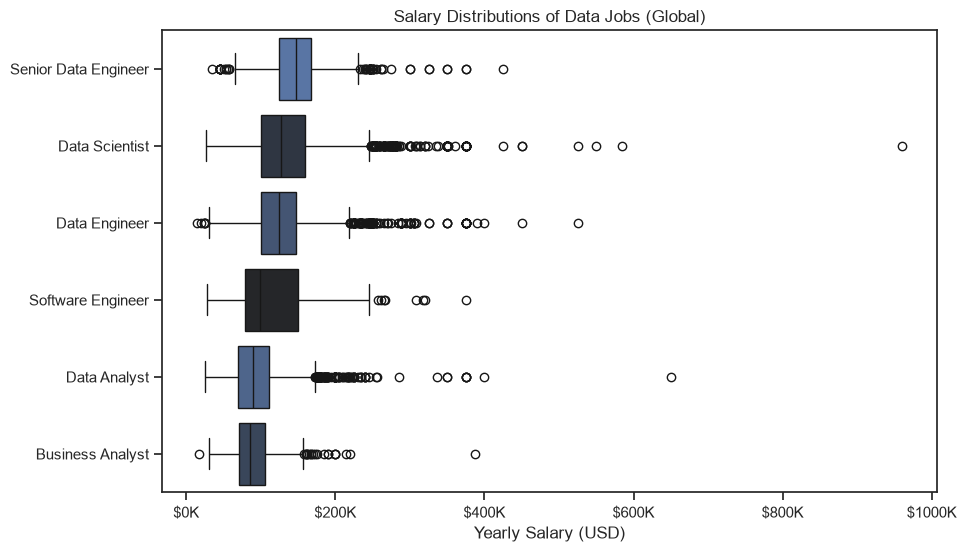

In [15]:
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df[df['job_title_short'].isin(job_titles)],
    x='salary_year_avg',
    y='job_title_short',
    order=df_job_order,
    ax=ax,
    palette='dark:b_r',
    hue='job_title_short',
    legend=False
)

sns.set_theme(style='ticks')

ax.set_title('Salary Distributions of Data Jobs (Global)')
ax.set_ylabel('')
ax.set_xlabel('Yearly Salary (USD)')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.show()

### 4. Investigate Median Salary vs Skill for Data Analysts

In [16]:
df_DA = df[(df['job_title_short'] == 'Data Analyst') & (df['salary_year_avg'].notna())].copy()

df_DA['job_skills'] = df_DA['job_skills'].apply(lambda x: x if isinstance(x, list) else [])
df_DA_exploded = df_DA.explode('job_skills')

### 5. Determine the Highest Paid Skills and Most Demanded Skills

In [17]:
df_DA_top_pay = (
    df_DA_exploded.groupby('job_skills')['salary_year_avg']
    .agg(['count', 'median'])
    .sort_values(by='median', ascending=False)
    .head(10)
)

df_DA_skills = (
    df_DA_exploded.groupby('job_skills')['salary_year_avg']
    .agg(['count', 'median'])
    .sort_values(by='count', ascending=False)
    .head(10)
)

### 6. Plot Salary Skill Distributions

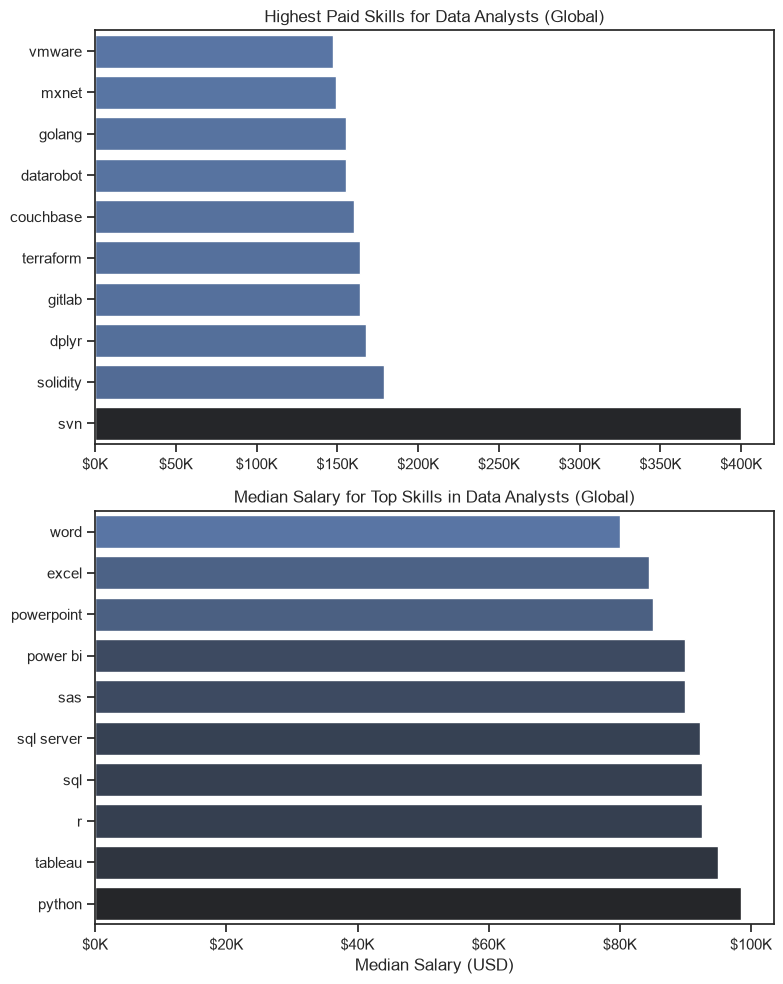

In [18]:
fig, ax = plt.subplots(2, 1, figsize=(8, 10))

sns.barplot(
    data=df_DA_top_pay.sort_values(by='median'),
    x='median',
    y=df_DA_top_pay.sort_values(by='median').index,
    ax=ax[0],
    hue='median',
    palette='dark:b_r',
    legend=False
)
ax[0].set_title('Highest Paid Skills for Data Analysts (Global)')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

sns.barplot(
    data=df_DA_skills.sort_values(by='median'),
    x='median',
    y=df_DA_skills.sort_values(by='median').index,
    ax=ax[1],
    hue='median',
    palette='dark:b_r',
    legend=False
)
ax[1].set_title('Median Salary for Top Skills in Data Analysts (Global)')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.tight_layout()
plt.show()